In [2]:
import sys
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

# Importation de VOS modules (Hybride approach)

from environments.market_env import MarketEnv
from agents.ddrl_agent import DDRLAgent

# Configuration pour jolis plots
sns.set_theme(style="whitegrid")


In [3]:
# === Paramètres de Simulation (Gârleanu & Pedersen Style) ===
params = {
    'horizon': 50,
    'num_samples': 10000,   # Moins que pour l'entraînement, juste pour tester
    'rho_alpha': 0.9,       # Mean reversion du signal
    'eta_alpha': 1.0,       # Volatilité du signal
    'risk_lambda': 1.0,     # Aversion au risque
    'cost_C': 4.0,          # Coût de transaction (TESTEZ : 4, 10, 20)
    'device': "cuda" if torch.cuda.is_available() else "cpu"
}


In [4]:
# Initialisation de l'environnement et de l'agent
env = MarketEnv(
    rho_alpha=params['rho_alpha'],
    eta_alpha=params['eta_alpha'],
    risk_lambda=params['risk_lambda'],
    cost_C=params['cost_C'],
    horizon=params['horizon'],
    device=params['device']
)

agent = DDRLAgent(env=env, horizon=params['horizon'], device=params['device'])

# CHARGEMENT DES POIDS (Supposons que vous avez lancé trainer.py avant)
# Si le fichier existe, on le charge. Sinon, on prévient l'utilisateur.
model_path = "policy_monoscale_quadratic.pt"
if os.path.exists(model_path):
    agent.policy.load_state_dict(torch.load(model_path))
    print(f"Modèle chargé depuis {model_path}")
    agent.policy.eval() # Mode évaluation
else:
    print("⚠️ Aucun modèle pré-entraîné trouvé. L'agent utilisera des poids aléatoires.")


Modèle chargé depuis policy_monoscale_quadratic.pt


In [5]:
# 1. Générer de nouveaux scénarios de marché (Out-of-sample)
print("Génération de scénarios de test...")
U_test, _ = env.generate_randomness(num_samples=1000)

# 2. Lancer la simulation (Rollout sans gradient)
with torch.no_grad():
    # On demande l'historique en mettant True
    rewards, states, actions = agent.rollout(U_test, return_history=True)
    
 
print(f"Récompense Moyenne sur 1000 scénarios : {rewards.mean().item():.4f}")


Génération de scénarios de test...
Récompense Moyenne sur 1000 scénarios : 69.5173


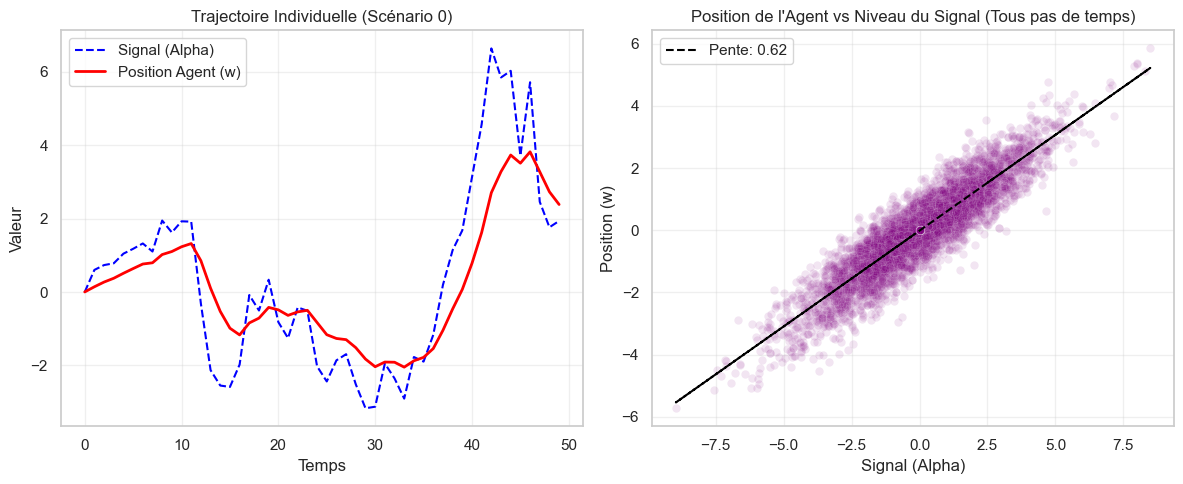

Analyse : Une pente positive (0.62) indique que l'agent achète bien quand le signal est positif.


In [6]:
# === Cellule 5 : Analyse des Trajectoires (Position vs Signal) ===

# Conversion des tenseurs PyTorch en tableaux NumPy pour l'affichage
# states : (batch, horizon, 2) -> index 0 = Alpha (Signal), index 1 = Position (w_t-1)
alphas_np = states[:, :, 0].cpu().numpy()
positions_np = states[:, :, 1].cpu().numpy()
actions_np = actions[:, :, 0].cpu().numpy()

# 1. Visualisation d'une trajectoire unique (Micro-Analyse)
# On prend le premier scénario du batch (index 0)
sample_idx = 0
time_steps = np.arange(params['horizon'])

plt.figure(figsize=(12, 5))

# Plot du Signal (Alpha) et de la Position de l'Agent
plt.subplot(1, 2, 1)
plt.plot(time_steps, alphas_np[sample_idx], label='Signal (Alpha)', color='blue', linestyle='--')
plt.plot(time_steps, actions_np[sample_idx], label='Position Agent (w)', color='red', linewidth=2)
plt.title(f"Trajectoire Individuelle (Scénario {sample_idx})")
plt.xlabel("Temps")
plt.ylabel("Valeur")
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Corrélation Globale : Position vs Signal
# L'agent doit théoriquement avoir une position proportionnelle au signal (w ~ k * alpha)
# On aplatit toutes les données de tous les scénarios et de tous les pas de temps
flat_alphas = alphas_np.flatten()
flat_positions = actions_np.flatten()

# On prend un sous-échantillon pour ne pas surcharger le scatter plot (ex: 5000 points)
idx = np.random.choice(len(flat_alphas), 5000, replace=False)

plt.subplot(1, 2, 2)
sns.scatterplot(x=flat_alphas[idx], y=flat_positions[idx], alpha=0.1, color="purple")
plt.title("Position de l'Agent vs Niveau du Signal (Tous pas de temps)")
plt.xlabel("Signal (Alpha)")
plt.ylabel("Position (w)")
# Ajout d'une ligne de régression pour voir la pente
m, b = np.polyfit(flat_alphas[idx], flat_positions[idx], 1)
plt.plot(flat_alphas[idx], m*flat_alphas[idx] + b, color='black', linestyle='--', label=f'Pente: {m:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Analyse : Une pente positive ({m:.2f}) indique que l'agent achète bien quand le signal est positif.")


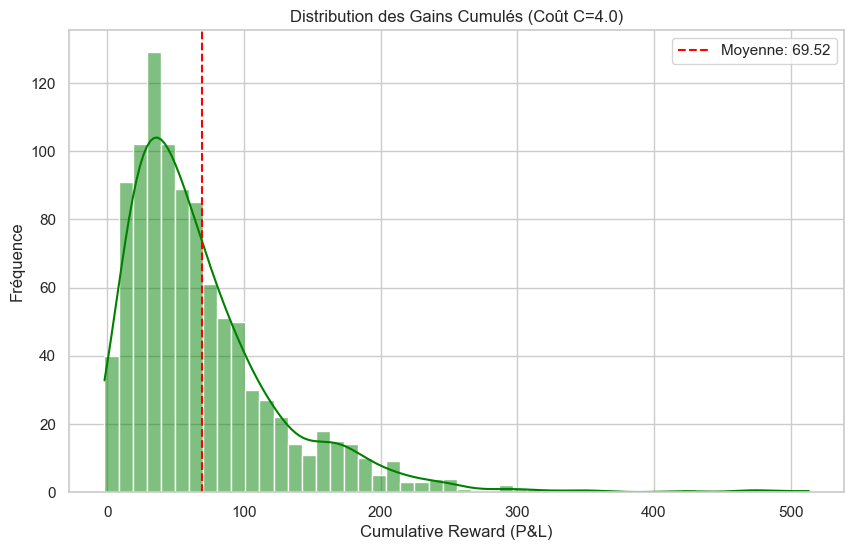

In [7]:
# Conversion en numpy pour plot
rewards_np = rewards.cpu().numpy()

# Histogramme des Profits (P&L)
plt.figure(figsize=(10, 6))
sns.histplot(rewards_np, kde=True, color="green", bins=50)
plt.title(f"Distribution des Gains Cumulés (Coût C={params['cost_C']})")
plt.xlabel("Cumulative Reward (P&L)")
plt.ylabel("Fréquence")
plt.axvline(x=rewards_np.mean(), color='red', linestyle='--', label=f'Moyenne: {rewards_np.mean():.2f}')
plt.legend()
plt.show()
